**Jack Dai**

CS 251/2: Data Analysis and Visualization


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams["figure.figsize"] = [12,4.5]

# Linear Regression Lab (Part A)

## Task 1: Mystery Data 1

### 1a. Import the data

1. Import data '`data/mystery_data_1.csv'` (using your data class or [genfromtxt](https://docs.scipy.org/doc/numpy/reference/generated/numpy.genfromtxt.html))
2. Print first 10 lines rows of data.


In [3]:
### BEGIN SOLUTION
data = np.genfromtxt(
    'data/mystery_data_1.csv',
    delimiter=',',
    skip_header=2 # header and type row
)
print('First 10 rows:')
print(data[:10])

### END SOLUTION

print('''
-----------------------------------
Your results should look like this:
-----------------------------------
First 10 rows:
[[ 9.185  0.536]
 [29.323 -3.209]
 [26.767  2.751]
 [17.792 -2.81 ]
 [14.624  2.409]
 [ 8.078  3.677]
 [ 3.736 -3.28 ]
 [10.999 -2.997]
 [18.113 -3.055]
 [ 3.33  -0.443]]
-----------------------------------
''')

First 10 rows:
[[ 9.185  0.536]
 [29.323 -3.209]
 [26.767  2.751]
 [17.792 -2.81 ]
 [14.624  2.409]
 [ 8.078  3.677]
 [ 3.736 -3.28 ]
 [10.999 -2.997]
 [18.113 -3.055]
 [ 3.33  -0.443]]

-----------------------------------
Your results should look like this:
-----------------------------------
First 10 rows:
[[ 9.185  0.536]
 [29.323 -3.209]
 [26.767  2.751]
 [17.792 -2.81 ]
 [14.624  2.409]
 [ 8.078  3.677]
 [ 3.736 -3.28 ]
 [10.999 -2.997]
 [18.113 -3.055]
 [ 3.33  -0.443]]
-----------------------------------



#### 1b. Using the following links and matplotlib documentation to view the data:

- [matplotlib](https://matplotlib.org/)
- [matplotlib hist](https://matplotlib.org/gallery/statistics/hist.html)

1. Create a figure with 3 subplots (each with a title):
   1. One scatterplot with column X on the x-axis and column Y on the y-axis.
   2. Two histograms: one for the X data, the other for the Y data. Use 10 bins in each histogram.


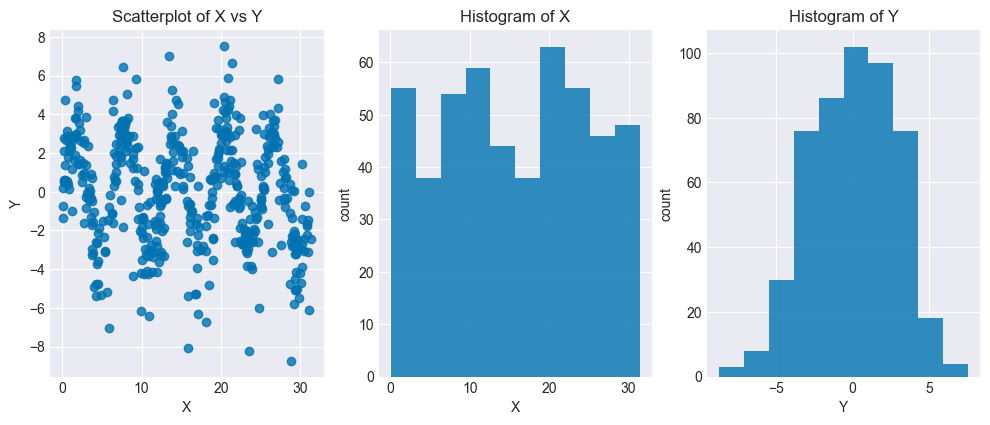

In [4]:
import matplotlib.pyplot as plt
x = data[:,0]
y = data[:,1]

fig, axes = plt.subplots(1, 3, figsize = (12,4.5))

# scatterplot
axes[0].scatter(x, y, alpha = 0.8)
axes[0].set_title('Scatterplot of X vs Y')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# histogram of X
axes[1].hist(x, bins=10, alpha = 0.8)
axes[1].set_title('Histogram of X')
axes[1].set_xlabel('X')
axes[1].set_ylabel('count')

# histogram of Y
axes[2].hist(y, bins=10, alpha = 0.8)
axes[2].set_title('Histogram of Y')
axes[2].set_xlabel('Y')
axes[2].set_ylabel('count')

plt.show()

## Task 2: Analyze Mystery Data 1

### 2a. Use scipy to calculate the linear regression for Mystery Data 1

Print first 10 lines rows of data.

Calculate the linear regression [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)

- The `a` parameter is the `A` array of independent data variables, the `b` parameter is the `y` array of the dependent variable values.
- Note that `A` matrix should include the column of 1s for the intercept.
- Useful: [hstack](https://docs.scipy.org/doc/numpy/reference/generated/numpy.hstack.html), [ones](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html) and `np.newaxis` (or [reshape](https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html)).

**NOTE:** One of the things that `scipy.linalg.lstsq` returns is the **residues**, which is another name for the sum of all the squared errors (**SSE**). This is different than the residuals, which refer to just the set of errors (i.e. differences between value on regression curve and actual data sample), not their sum of squares.

Print the least-squares solved coefficients and residues.

Using the SSE, calculate and print the $R^2$ value using the following equations:

$R^2 = 1 - \frac{SSE}{smd}$

The square mean deviation: $smd = \sum_i^N \left ( y_i - \frac{1}{N} \sum_i^N y_i \right )^2$


In [5]:
import scipy.linalg

In [11]:
print('Print first 10 lines rows of data:')
print(x[:10])
print(y[:10])

a = np.column_stack((x, np.ones_like(x)))
b = y

ones = np.ones((len(x), 1))
x_col = x[:, np.newaxis] # turns (N,) into (N,1)

A = np.hstack((ones, x_col))

# least squares
c, residues, rank, s = scipy. linalg.lstsq(A, b)

print('c:', c)

SSE = np.sum((y - a @ c)**2)
print('SSE:', SSE)

r2 = 1 - SSE / np.sum((y - np.mean(y))**2)
print('r2:', r2)

print('''
-----------------------------------
Your results should look like this:
----------------------------------- 
c: [ 0.92884793 -0.05650709]

SSE: 3722.8001542015754

r2: 0.033824411486558126
-----------------------------------
''')

Print first 10 lines rows of data:
[ 9.185 29.323 26.767 17.792 14.624  8.078  3.736 10.999 18.113  3.33 ]
[ 0.536 -3.209  2.751 -2.81   2.409  3.677 -3.28  -2.997 -3.055 -0.443]
c: [ 0.92884793 -0.05650709]
SSE: 147585.63257034772
r2: -37.30279077533943

-----------------------------------
Your results should look like this:
----------------------------------- 
c: [ 0.92884793 -0.05650709]

SSE: 3722.8001542015754

r2: 0.033824411486558126
-----------------------------------



### 2b. Visualize linear regression results with matplotlib

1. Plot a scatterplot of the mystery data X on the x axis and Y on the y axis
2. Plot a line representing the linear regression
   1. For line_x, use [linspace](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linspace.html) to create 100 points from the min x value to the max x value
   2. For line_y, multiply line_x by the slope and add the intercept
3. Include a title (with $R^2$ value), legend, x label and y label


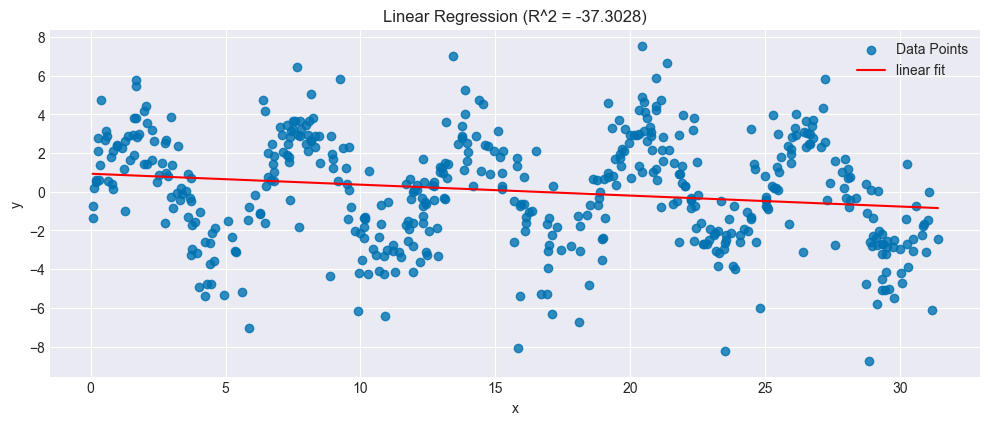

In [10]:
### BEGIN SOLUTION
m_x = np.linspace(np.min(x), np.max(x), 100)
line_x = np.linspace(np.min(x), np.max(x), 100)
lin_y = c[0] + c[1] * line_x #intercept + slope * x
plt.scatter(x, y, alpha = 0.8, label='Data Points')
plt.plot(line_x, lin_y, color='red', label='linear fit')
plt.title(f'Linear Regression (R^2 = {r2:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


### END SOLUTION

### 2c. Interpret the results of the linear regression of the dataset

**Question 1:** Interpret the results based on your plot and $R^2$ value. Is the linear regression model a good model for the data? **Why?**


**Answer 1:**
The plot shows a very low R^2. The linear model is not a good fit. It explains only a tiny fraction of the variance, so the data don’t show a strong linear relationship.
